<a href="https://colab.research.google.com/github/ayanategi689-boop/imageclassification-/blob/main/imageclassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces?%27")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ayanategi
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:06<00:00, 109MB/s]


In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device available: ", device)

Device available:  cuda


In [ ]:
image_path = []
lables = []

for i in os.listdir("/content/animal-faces/afhq"):
  for lable in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{lable}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{lable}/{image}")
      lables.append(lable)

data_df = pd.DataFrame(zip(image_path, lables), columns = ["image_path", "lables"])

print(data_df["lables"].unique())
data_df.head()

['wild' 'cat' 'dog']


,image_path,lables
0,/content/animal-faces/afhq/train/wild/flickr_w...,wild
1,/content/animal-faces/afhq/train/wild/flickr_w...,wild
2,/content/animal-faces/afhq/train/wild/flickr_w...,wild
3,/content/animal-faces/afhq/train/wild/flickr_w...,wild
4,/content/animal-faces/afhq/train/wild/pixabay_...,wild


In [ ]:
train = data_df.sample(frac = 0.7)
test = data_df.drop(train.index)

val = test.sample(frac = 0.5)
test = test.drop(val.index)

print(train.shape)
print(val.shape)
print(test.shape)


(11291, 2)
(2420, 2)
(2419, 2)


In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["lables"])


transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)

])

In [ ]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['lables'])).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    iabel = self.labels[idx]

    image = Image.open(img_path).convert('RGB') #read image

    if self.transform:
      image = self.transform(image).to(device)

    return image, iabel

In [ ]:
train_dataset = CustomImageDataset(dataframe = train, transform = transform)
val_dataset = CustomImageDataset(dataframe = val, transform = transform)
test_dataset = CustomImageDataset(dataframe = test, transform = transform)



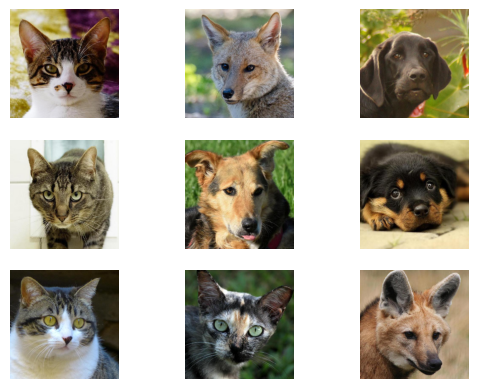

In [ ]:
"""
Each run will display random images
"""

# visualize images
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample (n = 1)["image_path"].iloc[0]).convert("RGB") # get a random image
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')

plt.show()

In [ ]:
# external configuration variables set before training begins (hyperparameters)
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [ ]:
# used to loop through data esaliy
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = True)

In [ ]:
#model class
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size = 3, padding = 1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size = 3, padding = 1)

    self.pooling = nn.MaxPool2d(2,2)

    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()
    self.linear1 = nn.Linear((128 * 16 * 16), 128)

    self.output = nn.Linear(128, len(data_df['lables'].unique()))

  def forward(self, x):
      # x goes into the first convolution layer
      x = self.conv1(x) # (32, 128, 128)
      x = self.pooling(x) # divide by 2 (32, 64, 64)
      x = self.relu(x)

      x = self.conv2(x) # (64, 64, 64)
      x = self.pooling(x) # divide by 2 (64, 32, 32)
      x = self.relu(x)

      x = self.conv3(x) # (128, 32, 32)
      x = self.pooling(x) # divide by 2 (128, 16, 16)
      x = self.relu(x)

      x = self.flatten(x)
      x = self.linear1(x)
      x = self.relu(x)
      x = self.output(x)

      return x

In [ ]:
# create network

model = Net().to(device)

In [ ]:
# model summary to check if calculations are correct
from torchsummary import summary
summary(model, input_size = (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
             ReLU-12                  [-1, 128]               0
           Linear-13                    [-1, 3]             387
Total params: 4,288,067
Trainable param

In [ ]:
# define the loss and optimizer

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [ ]:
"""
List that appends each value after each epoch to be plotted
"""

total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []


for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/(train_dataset.__len__())*100, 4))
  total_acc_validation_plot.append(round(total_acc_val/(val_dataset.__len__())*100, 4))
  print(f'''Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/100, 4)} Train Accuracy {round((total_acc_train)/train_dataset.__len__() * 100, 4)}
              Validation Loss: {round(total_loss_val/100, 4)} Validation Accuracy: {round((total_acc_val)/val_dataset.__len__() * 100, 4)}''')

Epoch 1/10, Train Loss: 3.7366 Train Accuracy 77.4865
              Validation Loss: 0.4693 Validation Accuracy: 88.7603
Epoch 2/10, Train Loss: 1.7456 Train Accuracy 90.8423
              Validation Loss: 0.3272 Validation Accuracy: 92.1901
Epoch 3/10, Train Loss: 1.238 Train Accuracy 93.6587
              Validation Loss: 0.2789 Validation Accuracy: 93.0165
Epoch 4/10, Train Loss: 0.908 Train Accuracy 95.4654
              Validation Loss: 0.2121 Validation Accuracy: 95.2066
Epoch 5/10, Train Loss: 0.7189 Train Accuracy 96.5371
              Validation Loss: 0.2226 Validation Accuracy: 94.7521
Epoch 6/10, Train Loss: 0.5504 Train Accuracy 97.2722
              Validation Loss: 0.2078 Validation Accuracy: 94.6281
Epoch 7/10, Train Loss: 0.4427 Train Accuracy 97.8567
              Validation Loss: 0.1853 Validation Accuracy: 95.7438
Epoch 8/10, Train Loss: 0.351 Train Accuracy 98.273
              Validation Loss: 0.1757 Validation Accuracy: 95.5785
Epoch 9/10, Train Loss: 0.2759 Train

In [ ]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0 # Initialize total_acc_test
  for inputs, labels in test_loader:
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc # Accumulate accuracy
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test/1000, 4)}")

Accuracy Score is: 95.4113 and Loss is 0.022


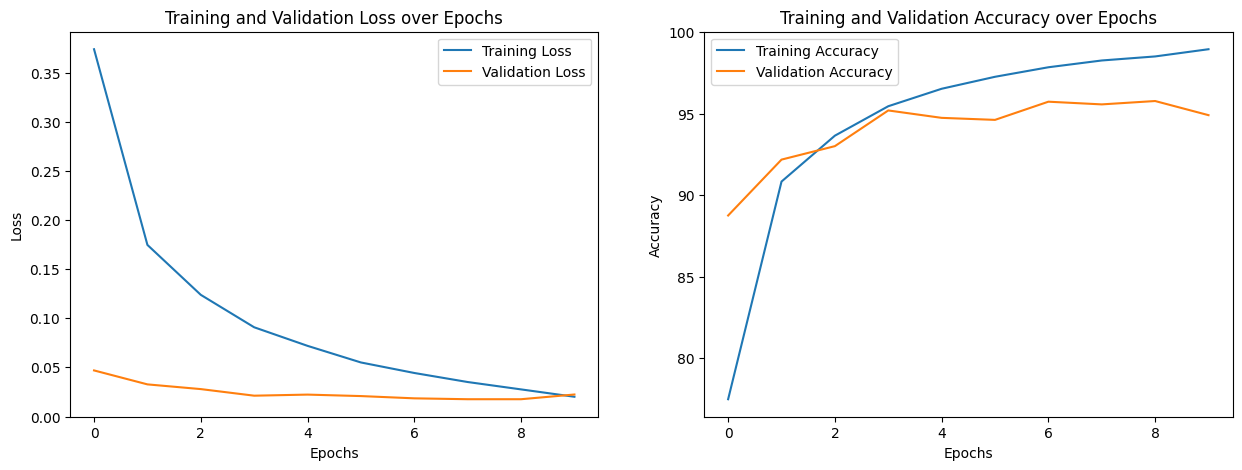

In [ ]:

fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5 ))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

In [ ]:
# 1) read image
# 2) transform using transform object
# 3) predict through the model
# 4) inverse transform by lebel encoder

def predict_image(image_path):
  image = Image.open(image_path).convert('RGB')
  image = transform(image).to(device)

  output = model(image.unsqueeze(0)) # we only have one image

  output = torch.argmax(output, axis = 1).item() #.item take out from memory
  return label_encoder.inverse_transform([output])



In [ ]:
predict_image("/content/breed_abyssinian_cat.jpg") # model will classify this as cat

array(['cat'], dtype=object)